In [1]:
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit import QuantumCircuit
from qiskit.circuit.library import n_local
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.optimizers import SPSA
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
#Building the frustrated Ising Hamiltonian with transverse field
N = 3; #Number of spins
coeffs = [0.5,0.5]; #[J,h]
H = ( SparsePauliOp.from_list([("ZZI", coeffs[0])]) +
          SparsePauliOp.from_list([("ZIZ", coeffs[0])]) +
          SparsePauliOp.from_list([("IZZ", coeffs[0])]) +
          SparsePauliOp.from_list([("XII", coeffs[1])]) +
          SparsePauliOp.from_list([("IXI", coeffs[1])]) + 
          SparsePauliOp.from_list([("IIX", coeffs[1])]) )

#Ry-CZ Ansatz for the trial wavefunction 

p = N*(3 + 1); #Total number of parameters with reps = 3;
ansatz = n_local(N, rotation_blocks = 'ry', entanglement_blocks = 'cz', reps=3)


#Defining the expectation value
def expectation_value(params):
    bound_qc = ansatz.assign_parameters(params)
    psi = Statevector(bound_qc)
    return psi.expectation_value(H).real

# Exact ground state
eigenvalues, eigenvectors = np.linalg.eigh(H.simplify().to_matrix())

In [3]:
#Run COBYLA and SPSA over multiple trials

N_TRIALS = 5
optimizers_cfg = {
    "COBYLA": COBYLA(maxiter=1000, tol=1e-6),
    "SPSA":   SPSA(maxiter=1000),
}

results_summary = {}

for opt_name, optimizer in optimizers_cfg.items():
    print(f"\n=== {opt_name} ===")
    trial_energies  = []
    trial_histories = []
    trial_times     = []

    for seed in range(N_TRIALS):
        rng = np.random.default_rng(seed)
        x0  = rng.uniform(-np.pi, np.pi, p)

        history = []

        # wrap expectation_value to record every function call
        def tracked_energy(params, _history=history):
            e = expectation_value(params)
            _history.append(e)
            return e

        t0     = time.perf_counter()
        result = optimizer.minimize(fun=tracked_energy, x0=x0)
        elapsed = time.perf_counter() - t0

        trial_energies.append(result.fun)
        trial_histories.append(history)
        trial_times.append(elapsed)
        print(f"  seed={seed}  E={result.fun:.6f}  nfev={result.nfev}  t={elapsed:.1f}s")

    results_summary[opt_name] = {
        "energies":  trial_energies,
        "histories": trial_histories,
        "times":     trial_times,
    }


=== COBYLA ===
  seed=0  E=-1.732051  nfev=1000  t=2.8s
  seed=1  E=-1.732051  nfev=1000  t=2.9s
  seed=2  E=-1.732051  nfev=294  t=0.8s
  seed=3  E=-1.732051  nfev=513  t=1.3s
  seed=4  E=-1.732051  nfev=583  t=1.6s

=== SPSA ===
  seed=0  E=-1.731824  nfev=2000  t=2.9s
  seed=1  E=-1.731999  nfev=2000  t=2.6s
  seed=2  E=-1.731733  nfev=2000  t=2.7s
  seed=3  E=-1.730386  nfev=2000  t=2.8s
  seed=4  E=-1.732017  nfev=2000  t=2.7s


Exact ground-state energy (ED): -1.732051


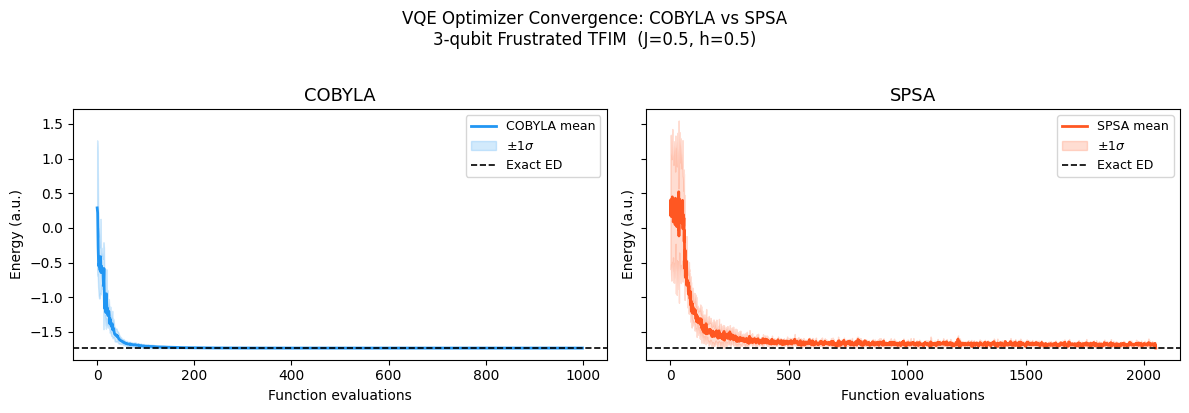

In [4]:
#Convergence plot

E_exact = eigenvalues[0]  # already computed above via np.linalg.eigh
print(f"Exact ground-state energy (ED): {E_exact:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
colors = {"COBYLA": "#2196F3", "SPSA": "#FF5722"}

for ax, (opt_name, data) in zip(axes, results_summary.items()):
    histories = data["histories"]
    max_len   = max(len(h) for h in histories)

    # pad shorter runs by holding their last value
    padded = np.array([h + [h[-1]] * (max_len - len(h)) for h in histories])
    iters  = np.arange(max_len)
    mean   = padded.mean(axis=0)
    std    = padded.std(axis=0)

    ax.plot(iters, mean, color=colors[opt_name], lw=2, label=f"{opt_name} mean")
    ax.fill_between(iters, mean - std, mean + std,
                    color=colors[opt_name], alpha=0.2, label=r"$\pm 1\sigma$")
    ax.axhline(E_exact, color="black", ls="--", lw=1.2, label="Exact ED")
    ax.set_title(opt_name, fontsize=13)
    ax.set_xlabel("Function evaluations")
    ax.set_ylabel("Energy (a.u.)")
    ax.legend(fontsize=9)

fig.suptitle("VQE Optimizer Convergence: COBYLA vs SPSA\n3-qubit Frustrated TFIM  (J=0.5, h=0.5)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("convergence_cobyla_spsa.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
print(f"\n{'Optimizer':<10} {'Mean E':>10} {'Std E':>8} {'|Error| vs ED':>14} {'Mean t (s)':>11}")
print("-" * 57)
for opt_name, data in results_summary.items():
    energies = np.array(data["energies"])
    print(f"{opt_name:<10} {energies.mean():>10.6f} {energies.std():>8.6f} "
          f"{abs(energies.mean() - E_exact):>14.6f} {np.mean(data['times']):>11.2f}")


Optimizer      Mean E    Std E  |Error| vs ED  Mean t (s)
---------------------------------------------------------
COBYLA      -1.732051 0.000000       0.000000        1.89
SPSA        -1.731592 0.000612       0.000459        2.76
